# Welcome

This is a notebook for the talk "On Evaluation Metrics of Speech Deepfake Detection – Lessons Learned from ASVSpoof" at ESDD Grand CHallenge ICME 2026.


The notebook is self explained.

```bash
by Xin Wang National Institute of Informatics
© 2026, Xin Wang.

All rights reserved. This work is licensed under the Creative Commons Attribution 3.0 license. See http://creativecommons.org/ for details.
```

# Functions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm


In [ ]:
def compute_dcf(frr, far, cost_fr, cost_fa, prior_pos, norm=True):
    """
    Computes the Detection Cost Function (DCF).

    Parameters:
    - frr: False Reject Rate (FN / Total True Positives)
    - far: False Acceptance Rate (FP / Total True Negatives)
    - cost_fr: Cost assigned to a False Reject (Miss)
    - cost_fa: Cost assigned to a False Acceptance (False Alarm)
    - prior_pos: Prior probability of the true/target/positive class
    - norm: Bool, whether norm the dcf by dcf/(cost_fa*prior_pos)
            default True

    Returns:
    - dcf: The calculated detection cost.
    """
    prior_neg = 1.0 - prior_pos
    dcf = (cost_fr * frr * prior_pos) + (cost_fa * far * prior_neg)
    if norm:
        dcf = dcf / (cost_fa * prior_neg + cost_fr * prior_pos)
    return dcf




def compute_eer(target_scores, nontarget_scores):
    """
    eer, eer_threshold = compute_eer(target_scores, nontarget_scores)

    input
    -----
      target_scores:    np.array, or list of np.array, target trial scores
      nontarget_scores: np.array, or list of np.array, nontarget trial scores

    output
    ------
      eer:            float, EER
      eer_threshold:  float, threshold corresponding to EER

    """
    frr, far, thr = compute_det_curve(target_scores, nontarget_scores)

    # find the operation point for EER
    abs_diffs = np.abs(frr - far)
    min_index = np.argmin(abs_diffs)

    # compute EER
    eer = np.mean((frr[min_index], far[min_index]))
    return eer, thr[min_index]



def compute_det_curve(target_scores, nontarget_scores):
    """
    frr, far, thr = compute_det_curve(target_scores, nontarget_scores)

    input
    -----
      target_scores:    np.array, target trial scores
      nontarget_scores: np.array, nontarget trial scores

    output
    ------
      frr:   np.array, FRR, (#N, ), where #N is total number of scores + 1
      far:   np.array, FAR, (#N, ), where #N is total number of scores + 1
      thr:   np.array, threshold, (#N, )

    """

    n_scores = target_scores.size + nontarget_scores.size
    all_scores = np.concatenate((target_scores, nontarget_scores))
    labels = np.concatenate((np.ones(target_scores.size),
                             np.zeros(nontarget_scores.size)))

    # Sort labels based on scores
    indices = np.argsort(all_scores, kind='mergesort')
    labels = labels[indices]

    # Compute false rejection and false acceptance rates
    tar_trial_sums = np.cumsum(labels)
    nontarget_trial_sums = (nontarget_scores.size -
                            (np.arange(1, n_scores + 1) - tar_trial_sums))

    frr = np.concatenate((np.atleast_1d(0), tar_trial_sums/target_scores.size))
    # false rejection rates
    far = np.concatenate((np.atleast_1d(1),
                          nontarget_trial_sums / nontarget_scores.size))
    # false acceptance rates
    thresholds = np.concatenate((np.atleast_1d(all_scores[indices[0]] - 0.001),
                                 all_scores[indices]))
    # Thresholds are the sorted scores
    return frr, far, thresholds


def compute_frr(true_scores, threshold):
    """
    Computes False Reject Rate (FRR): True samples that fall below the threshold.
    """
    # Assuming higher scores mean more likely to be 'true/target class'
    false_rejects = np.sum(true_scores < threshold)
    frr = false_rejects / len(true_scores)
    return frr

def compute_far(false_scores, threshold):
    false_accepts = np.sum(false_scores >= threshold)
    far = false_accepts / len(false_scores)
    return far


def compute_bayes_tau(cost_fr, cost_fa, prior_pos):
    """
    Computes the Bayes decision threshold

    Parameters:
    - cost_fr: Cost assigned to a False Reject (Miss)
    - cost_fa: Cost assigned to a False Acceptance (False Alarm)
    - prior_pos: Prior probability of the true/target/positive class

    Returns:
    - tau: decision threshold for optimal Bayes decision
           (using LLR)

    See discussion under Eq.(1) 10.1109/TASLPRO.2026.3682962
    """
    beta = cost_fr * prior_pos / (cost_fa * (1-prior_pos))
    return -np.log(beta)


In [ ]:
#!/usr/bin/env python
"""
This module is based on Cllr and min Cllr implemented by Dr. Andreas Nautsch

https://gitlab.eurecom.fr/nautsch/cllr

license: LGPLv3
version: 2020-01-10
author: Andreas Nautsch (EURECOM)
"""

import numpy
import copy

def logit(p):
    """logit function.
    This is a one-to-one mapping from probability to log-odds.
    i.e. it maps the interval (0,1) to the real line.
    The inverse function is given by SIGMOID.

    log_odds = logit(p) = log(p/(1-p))

    :param p: the inumpyut value

    :return: logit(inumpyut)
    """
    p = numpy.array(p)
    lp = numpy.zeros(p.shape)
    f0 = p == 0
    f1 = p == 1
    f = (p > 0) & (p < 1)

    if lp.shape == ():
        if f:
            lp = numpy.log(p / (1 - p))
        elif f0:
            lp = -numpy.inf
        elif f1:
            lp = numpy.inf
    else:
        lp[f] = numpy.log(p[f] / (1 - p[f]))
        lp[f0] = -numpy.inf
        lp[f1] = numpy.inf
    return lp


def sigmoid(log_odds):
    """SIGMOID: Inverse of the logit function.
    This is a one-to-one mapping from log odds to probability.
    i.e. it maps the real line to the interval (0,1).

    p = sigmoid(log_odds)

    :param log_odds: the inumpyut value

    :return: sigmoid(inumpyut)
    """
    p = 1 / (1 + numpy.exp(-log_odds))
    return p

def pavx(y):
    """PAV: Pool Adjacent Violators algorithm.
    Non-paramtetric optimization subject to monotonicity.

    ghat = pav(y)
    fits a vector ghat with nondecreasing components to the
    data vector y such that sum((y - ghat).^2) is minimal.
    (Pool-adjacent-violators algorithm).

    optional outputs:
            width: width of pav bins, from left to right
                    (the number of bins is data dependent)
            height: corresponding heights of bins (in increasing order)

    Author: This code is a simplified version of the 'IsoMeans.m' code
    made available by Lutz Duembgen at:
    http://www.imsv.unibe.ch/~duembgen/software

    :param y: inumpyut value
    """
    assert y.ndim == 1, 'Argument should be a 1-D array'
    assert y.shape[0] > 0, 'Inumpyut array is empty'
    n = y.shape[0]

    index = numpy.zeros(n, dtype=int)
    length = numpy.zeros(n, dtype=int)

    ghat = numpy.zeros(n)

    ci = 0
    index[ci] = 1
    length[ci] = 1
    ghat[ci] = y[0]

    for j in range(1, n):
        ci += 1
        index[ci] = j + 1
        length[ci] = 1
        ghat[ci] = y[j]
        while (ci >= 1) & (ghat[numpy.max(ci - 1, 0)] >= ghat[ci]):
            nw = length[ci - 1] + length[ci]
            ghat[ci - 1] = ghat[ci - 1] + (length[ci] / nw) * (ghat[ci] - ghat[ci - 1])
            length[ci - 1] = nw
            ci -= 1

    height = copy.deepcopy(ghat[:ci + 1])
    width = copy.deepcopy(length[:ci + 1])

    while n >= 0:
        for j in range(index[ci], n + 1):
            ghat[j - 1] = ghat[ci]
        n = index[ci] - 1
        ci -= 1

    return ghat, width, height


def optimal_llr(tar, non, laplace=False,
                monotonicity_epsilon=1e-6, compute_eer=False):
    """

    input
    -----
      tar_llrs:    np.array (N, ), null hypothesis LLRs
      nontar_llrs: np.array (M, ), alter hypothesis LLRs
      laplace:     bool,

    output
    ------
      c: scalar, Cllr value

    Comment by original author:
    Laplace flag avoids infinite LLR magnitudes;
    also, this stops DET cureves from 'curling' to the axes on sparse data
    (DETs stay in more populated regions)
    """

    scores = numpy.concatenate([non, tar])
    Pideal = numpy.concatenate([numpy.zeros(len(non)), numpy.ones(len(tar))])

    perturb = numpy.argsort(scores, kind='mergesort')
    Pideal = Pideal[perturb]

    if laplace:
        Pideal = numpy.hstack([1, 0, Pideal, 1, 0])

    Popt, width, foo = pavx(Pideal)

    if laplace:
        Popt = Popt[2:len(Popt) - 2]

    posterior_log_odds = logit(Popt)
    log_prior_odds = numpy.log(len(tar) / len(non))
    llrs = posterior_log_odds - log_prior_odds
    N = len(tar) + len(non)
    llrs = llrs + numpy.arange(N) * monotonicity_epsilon / N  # preserve monotonicity

    idx_reverse = numpy.zeros(len(scores), dtype=int)
    idx_reverse[perturb] = numpy.arange(len(scores))
    tar_llrs = llrs[idx_reverse][len(non):]
    nontar_llrs = llrs[idx_reverse][:len(non)]

    if not compute_eer:
        return tar_llrs, nontar_llrs

    nbins = width.shape[0]
    pmiss = numpy.zeros(nbins + 1)
    pfa = numpy.zeros(nbins + 1)
    #
    # threshold leftmost: accept everything, miss nothing
    left = 0  # 0 scores to left of threshold
    fa = non.shape[0]
    miss = 0
    #
    for i in range(nbins):
        pmiss[i] = miss / len(tar)
        pfa[i] = fa /len(non)
        left = int(left + width[i])
        miss = numpy.sum(Pideal[:left])
        fa = len(tar) + len(non) - left - numpy.sum(Pideal[left:])
    #
    pmiss[nbins] = miss / len(tar)
    pfa[nbins] = fa / len(non)

    eer = 0
    for i in range(pfa.shape[0] - 1):
        xx = pfa[i:i + 2]
        yy = pmiss[i:i + 2]

        # xx and yy should be sorted:
        assert (xx[1] <= xx[0]) & (yy[0] <= yy[1]), \
            'pmiss and pfa have to be sorted'

        XY = numpy.column_stack((xx, yy))
        dd = numpy.dot(numpy.array([1, -1]), XY)
        if numpy.min(numpy.abs(dd)) == 0:
            eerseg = 0
        else:
            # find line coefficients seg s.t. seg'[xx(i);yy(i)] = 1,
            # when xx(i),yy(i) is on the line.
            seg = numpy.linalg.solve(XY, numpy.array([[1], [1]]))
            # candidate for EER, eer is highest candidate
            eerseg = 1 / (numpy.sum(seg))

        eer = max([eer, eerseg])
    return tar_llrs, nontar_llrs, eer




In [ ]:
# plotting
def plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=False):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ax1 = axes[0]
    ax1.hist(neg_scores, bins=50, alpha=0.6, color='red', label='Negative (non/fake)', density=True)
    ax1.hist(pos_scores, bins=50, alpha=0.6, color='blue', label='Positive (tar/real)', density=True)

    # Add KDE curves using scipy for smoother visualization
    xmin, xmax = ax1.get_xlim()
    x_axis = np.linspace(xmin, xmax, 200)
    #ax1.plot(x_axis, norm.pdf(x_axis, neg_mean, neg_std), color='darkred', lw=2)
    #ax1.plot(x_axis, norm.pdf(x_axis, pos_mean, pos_std), color='darkblue', lw=2)

    #ax1.set_title('Score Distribution & Decision Boundary', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Detector score')
    ax1.set_ylabel('Density')
    ax1.legend(frameon=True)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- Plot 2: DCF against Prior ---
    ax2 = axes[1]

    ax2.plot(bayes_thresholds, dcf_values, color='black', label=f'DCF (normed)')

    #ax2.set_title('Detection Cost Function (DCF) vs. True Prior', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Bayes decision threshold (function of prior & costs)')
    ax2.set_ylabel('Detection Cost (normed)')

    if with_baseline:
        # for each prior (and bayes threshold)
        frrs_dummy = np.array([compute_frr(np.zeros_like(pos_scores), x) for x in bayes_thresholds])
        fars_dummy = np.array([compute_far(np.zeros_like(neg_scores), x) for x in bayes_thresholds])

        # decision costs
        dcf_values_dummy = compute_dcf(frr=frrs_dummy, far=fars_dummy, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
        ax2.plot(bayes_thresholds, dcf_values_dummy, color='grey', linestyle=':', label=f'Random guess')

    ax2.legend(frameon=True)
    ax2.grid(True, linestyle=':', alpha=0.6)

    return plt, [ax1, ax2]

# Simulation data

A simple demonstration where we vary prior, and use equal decision costs

In [ ]:
# for simple demonstration, set C_FR = C_FA = 1.0
C_FR = 1.0
C_FA = 1.0

# check many priories
priors_pos = np.linspace(0.0001, 1-0.0001, 1000)


(-4.3, 4.3)

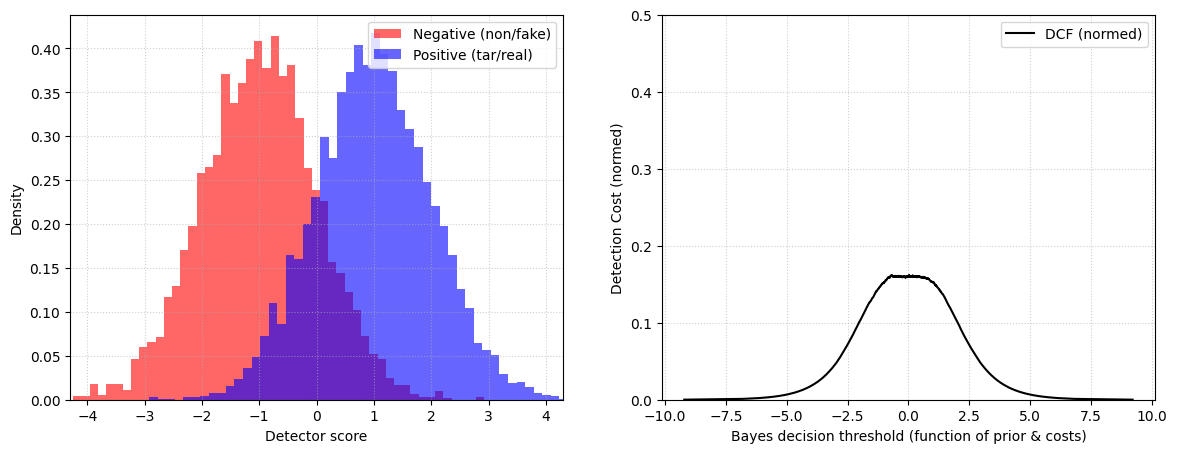

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = -1, 1
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000)
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds)
axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

(-4.3, 4.3)

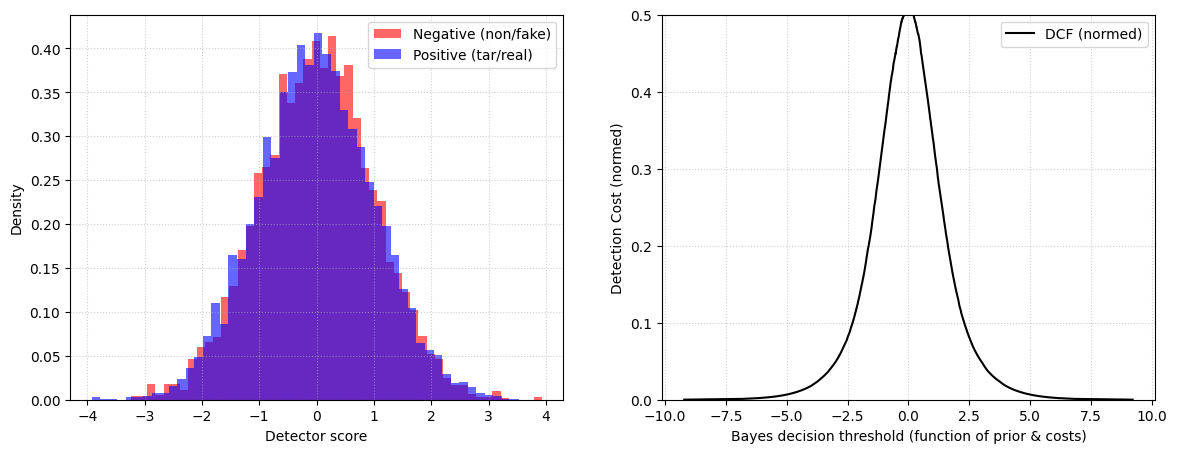

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = 0, 0
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000)
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds)

axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

(-4.3, 4.3)

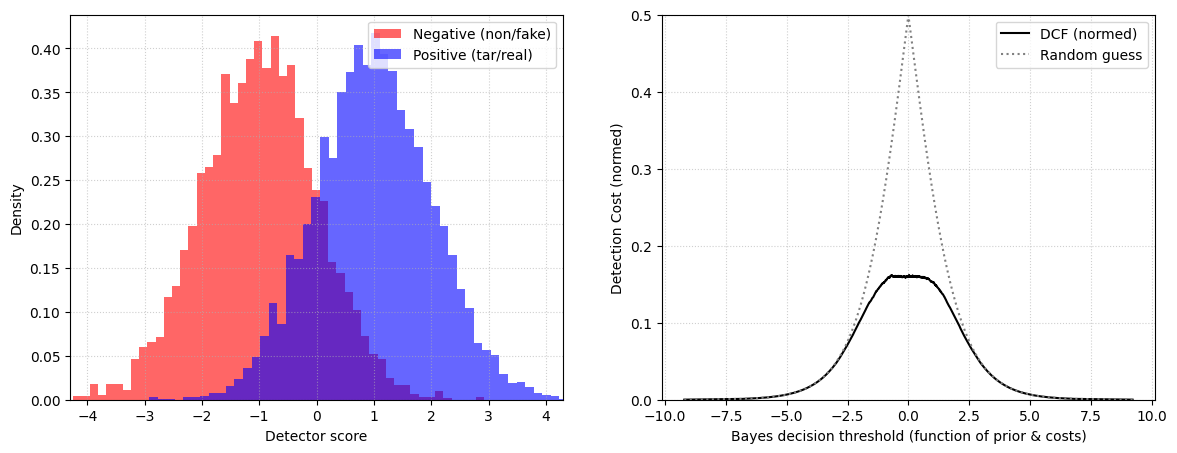

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = -1, 1
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000)
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes =plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)
axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

(-4.3, 4.3)

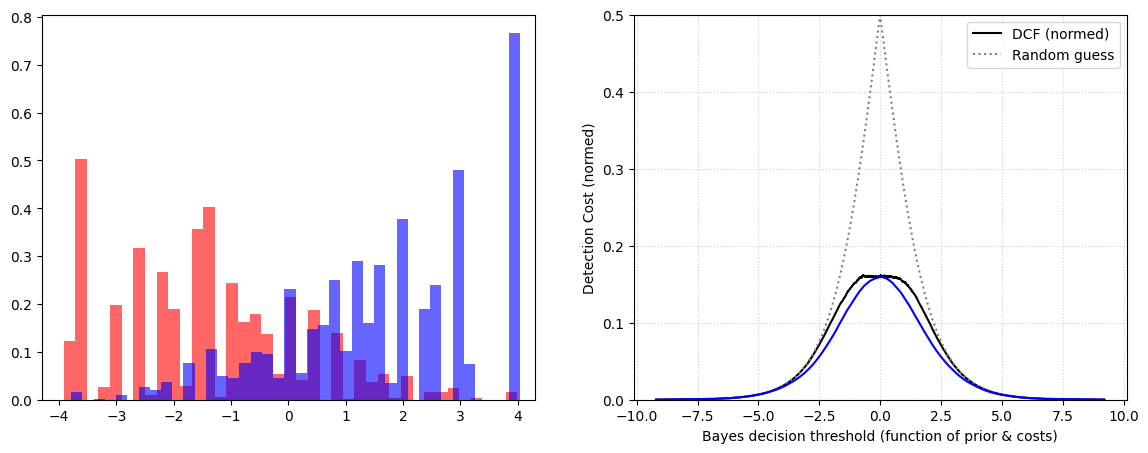

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = -1, 1
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000)
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)


# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes =plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

# PAV
# fix it by converting posteriors to LLR-like
pos_scores_pav, neg_scores_pav = optimal_llr(pos_scores, neg_scores,laplace=True)

axes[0].clear()
axes[0].hist(neg_scores_pav, bins=50, alpha=0.6, color='red', label='Negative (non/fake)', density=True)
axes[0].hist(pos_scores_pav, bins=50, alpha=0.6, color='blue', label='Positive (tar/real)', density=True)

# for each prior (and bayes threshold)
frrs_pav = np.array([compute_frr(pos_scores_pav, x) for x in bayes_thresholds])
fars_pav = np.array([compute_far(neg_scores_pav, x) for x in bayes_thresholds])
dcf_values_pav = compute_dcf(frr=frrs_pav, far=fars_pav, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_pav, color='b')

axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

(-4.3, 4.3)

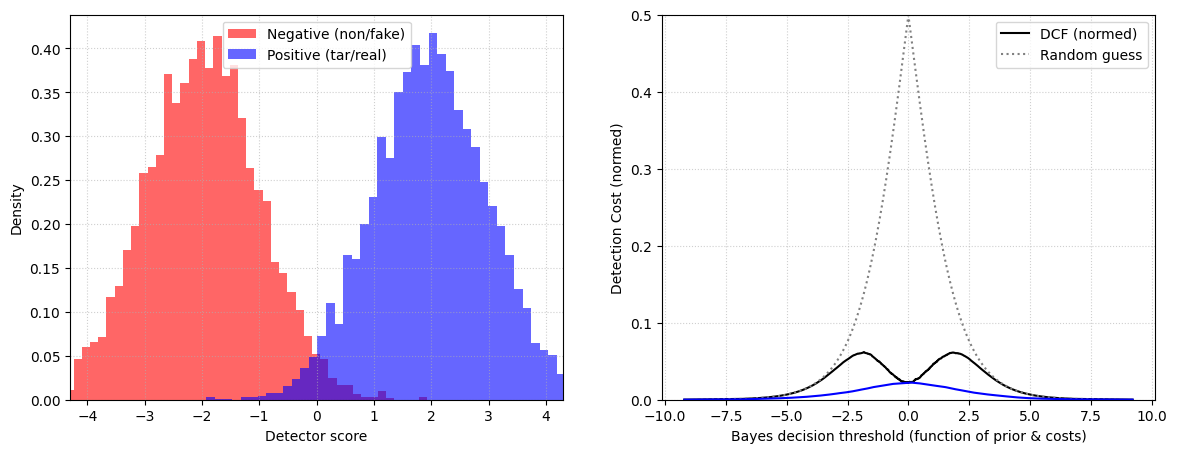

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = -2, 2
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000)
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes =plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

# PAV
# fix it by converting posteriors to LLR-like
pos_scores_pav, neg_scores_pav = optimal_llr(pos_scores, neg_scores,laplace=True)

# for each prior (and bayes threshold)
frrs_pav = np.array([compute_frr(pos_scores_pav, x) for x in bayes_thresholds])
fars_pav = np.array([compute_far(neg_scores_pav, x) for x in bayes_thresholds])
dcf_values_pav = compute_dcf(frr=frrs_pav, far=fars_pav, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_pav, color='b')

axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

(-4.3, 4.3)

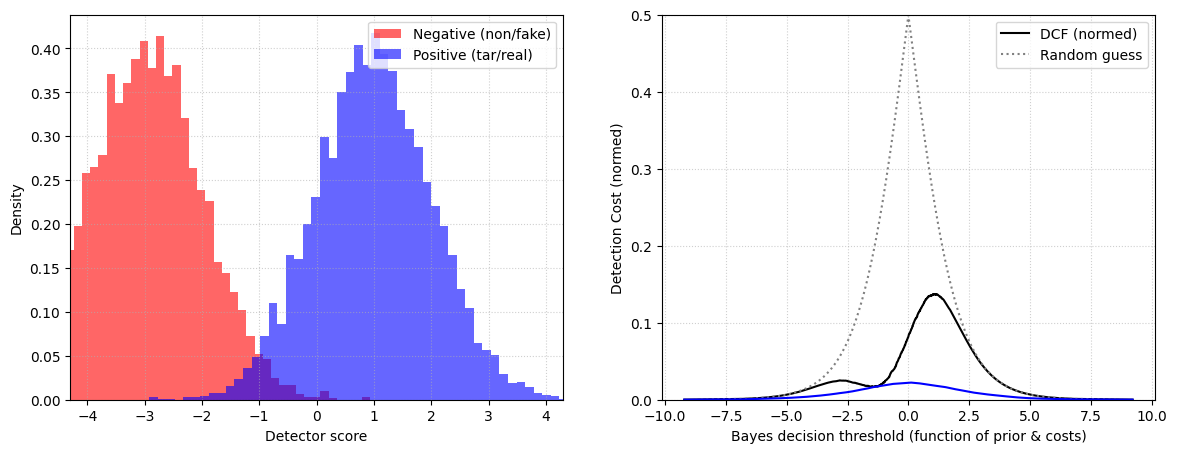

In [ ]:
# Generating simulated data
np.random.seed(42)

# Generate synthetic scores (e.g., log-likelihood ratios or model outputs)
# False class (Negative) has a lower mean, True class (Positive) has a higher mean
neg_mean, pos_mean = -2, 2
neg_std, pos_std = 1, 1
neg_scores = np.random.normal(loc=neg_mean, scale=neg_std, size=5000) - 1.0
pos_scores = np.random.normal(loc=pos_mean, scale=pos_std, size=5000) - 1.0

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes =plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

# PAV
# fix it by converting posteriors to LLR-like
pos_scores_pav, neg_scores_pav = optimal_llr(pos_scores, neg_scores,laplace=True)

# for each prior (and bayes threshold)
frrs_pav = np.array([compute_frr(pos_scores_pav, x) for x in bayes_thresholds])
fars_pav = np.array([compute_far(neg_scores_pav, x) for x in bayes_thresholds])
dcf_values_pav = compute_dcf(frr=frrs_pav, far=fars_pav, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_pav, color='b')

axes[-1].set_ylim(0, 0.5)
axes[-2].set_xlim(-4.3, 4.3)

# Using data from ASVspoof5

Demonstration using two ASVspoof5 challenge participants scores

In [ ]:
# Download sample data
!gdown 1miENjjfS6UbS9yoKUqys3XUTrs13DxSc
!gdown 1E3KNvlro0SLil9BVDG5wjUee9D-3JV8F

Downloading...
From: https://drive.google.com/uc?id=1miENjjfS6UbS9yoKUqys3XUTrs13DxSc
To: /content/case2_score_key_meta.pkl
100% 61.8M/61.8M [00:00<00:00, 103MB/s]
Downloading...
From: https://drive.google.com/uc?id=1E3KNvlro0SLil9BVDG5wjUee9D-3JV8F
To: /content/case1_score_key_meta.pkl
100% 61.8M/61.8M [00:00<00:00, 88.9MB/s]


In [ ]:
import pickle
with open('case1_score_key_meta.pkl', 'rb') as file_ptr:
    t1_data = pickle.load(file_ptr)
with open('case2_score_key_meta.pkl', 'rb') as file_ptr:
    t2_data = pickle.load(file_ptr)

In [ ]:
# parameters used in ASVspoof5
C_FR = 1.0
C_FA = 10.0


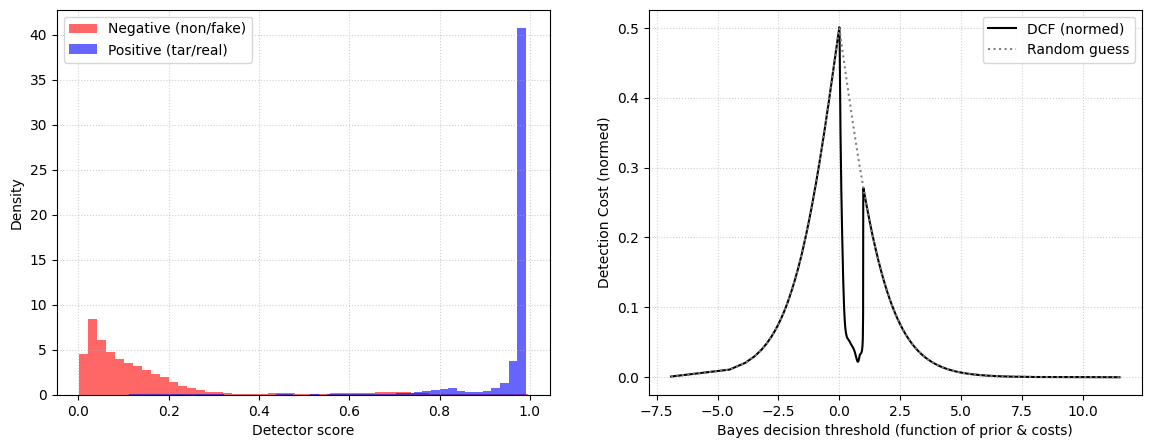

In [ ]:
# case 1

pos_scores = t1_data.query('cm_label == "bonafide"')['cm-score'].to_numpy()
neg_scores = t1_data.query('cm_label != "bonafide"')['cm-score'].to_numpy()

# check many priories
priors_pos = np.linspace(0.0001, 1-0.0001, 1000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

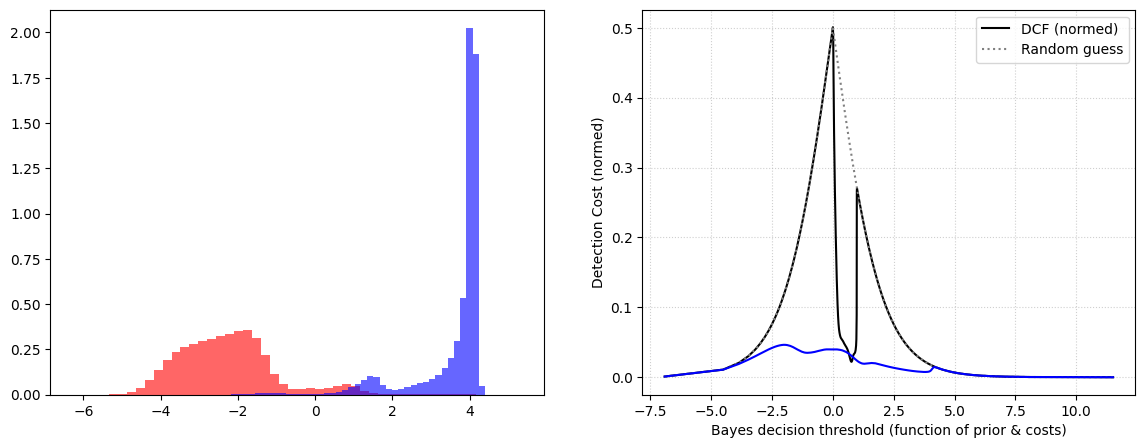

In [ ]:
# fix case 1 by using heuristic
fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

# fix it by converting posteriors to LLR-like
pos_scores_ = np.log(pos_scores / (1-pos_scores))
neg_scores_ = np.log(neg_scores / (1-neg_scores))

# for each prior (and bayes threshold)
frrs_ = np.array([compute_frr(pos_scores_, x) for x in bayes_thresholds])
fars_ = np.array([compute_far(neg_scores_, x) for x in bayes_thresholds])

# decision costs
dcf_values_ = compute_dcf(frr=frrs_, far=fars_, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[0].clear()
axes[0].hist(neg_scores_, bins=50, alpha=0.6, color='red', label='Negative (non/fake)', density=True)
axes[0].hist(pos_scores_, bins=50, alpha=0.6, color='blue', label='Positive (tar/real)', density=True)
axes[-1].plot(bayes_thresholds, dcf_values_, color='b')

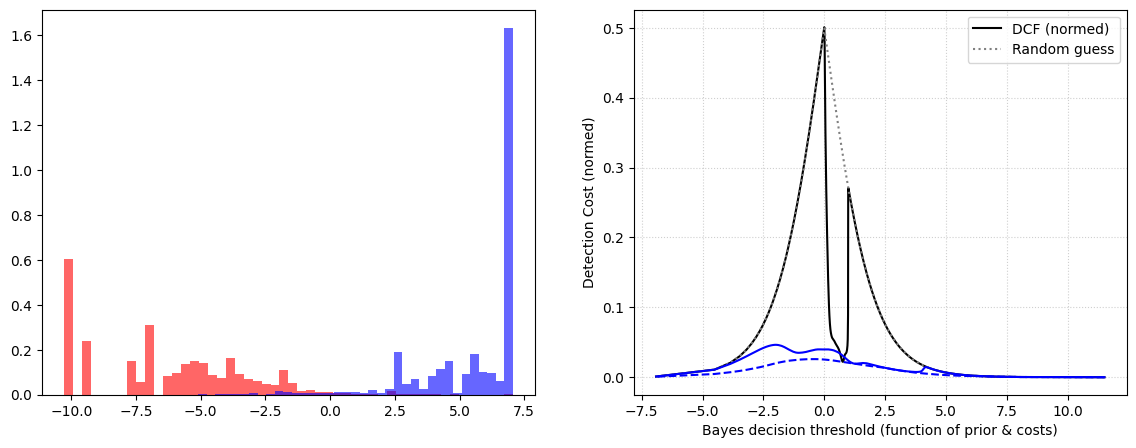

In [ ]:
# fix case 1 by using PAV

# original figure
fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)

# heuristic fix
dcf_values_ = compute_dcf(frr=frrs_, far=fars_, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_, color='b')


# PAV
# fix it by converting posteriors to LLR-like
pos_scores_pav, neg_scores_pav = optimal_llr(pos_scores, neg_scores,laplace=True)

axes[0].clear()
axes[0].hist(neg_scores_pav, bins=50, alpha=0.6, color='red', label='Negative (non/fake)', density=True)
axes[0].hist(pos_scores_pav, bins=50, alpha=0.6, color='blue', label='Positive (tar/real)', density=True)

# for each prior (and bayes threshold)
frrs_pav = np.array([compute_frr(pos_scores_pav, x) for x in bayes_thresholds])
fars_pav = np.array([compute_far(neg_scores_pav, x) for x in bayes_thresholds])
dcf_values_pav = compute_dcf(frr=frrs_pav, far=fars_pav, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_pav, color='b', linestyle='--')


In [ ]:
# the heuriestic does not change EER
print(compute_eer(pos_scores, neg_scores)[0] * 100)
print(compute_eer(pos_scores_, neg_scores_)[0] * 100)
print(compute_eer(pos_scores_pav, neg_scores_pav)[0] * 100)

2.5942751140694718
2.5942751140694718
2.5942751140694718


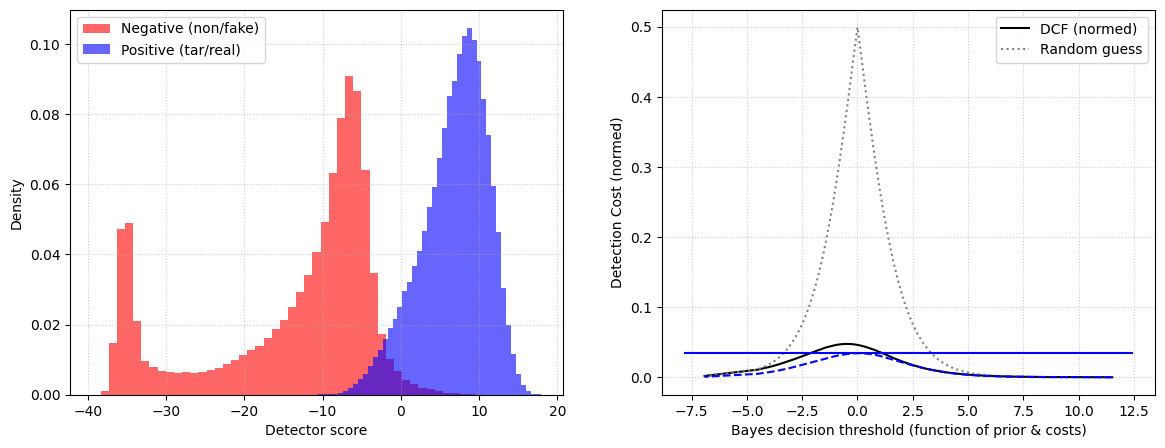

In [ ]:
# case 1

pos_scores = t2_data.query('cm_label == "bonafide"')['cm-score'].to_numpy()
neg_scores = t2_data.query('cm_label != "bonafide"')['cm-score'].to_numpy()

# check many priories
priors_pos = np.linspace(0.0001, 1-0.0001, 1000)

# corresponding Bayes decision thresholds
bayes_thresholds = compute_bayes_tau(C_FR, C_FA, priors_pos)

# for each prior (and bayes threshold)
frrs = np.array([compute_frr(pos_scores, x) for x in bayes_thresholds])
fars = np.array([compute_far(neg_scores, x) for x in bayes_thresholds])

# decision costs
dcf_values = compute_dcf(frr=frrs, far=fars, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)

fig, axes = plotting(pos_scores, neg_scores, frrs, fars, dcf_values, bayes_thresholds, with_baseline=True)


# PAV
# fix it by converting posteriors to LLR-like
pos_scores_pav, neg_scores_pav = optimal_llr(pos_scores, neg_scores,laplace=True)

# for each prior (and bayes threshold)
frrs_pav = np.array([compute_frr(pos_scores_pav, x) for x in bayes_thresholds])
fars_pav = np.array([compute_far(neg_scores_pav, x) for x in bayes_thresholds])
dcf_values_pav = compute_dcf(frr=frrs_pav, far=fars_pav, cost_fa=C_FA, cost_fr=C_FR, prior_pos=priors_pos, norm=True)
axes[-1].plot(bayes_thresholds, dcf_values_pav, color='b', linestyle='--')

# the heuriestic does not change EER
eer_value = compute_eer(pos_scores_pav, neg_scores_pav)[0]
axes[-1].hlines(eer_value, xmin=axes[-1].get_xlim()[0], xmax=axes[-1].get_xlim()[1], color='b')


Acknowledgement: I thank the ASVspoof 5 participants & organizing team for allowing me to share the findings.